# R Coursework part 1

Answer all of the questions below in the cells provided. 

Make sure you:

- comment your code
- run your cells to check your answers
- save your notebook with your answers before submitting it

### Question 1

Create a data frame with 5 rows and 2 columns. The first column should be a vector of names of your choice, the second should be a series of numeric values.

In [1]:
names <- c("Harry","Ella","John","Sarah","Joe")
numbers <- c(1, 15, 25, 8, 19)
df <- data.frame(names, numbers)


### Question 2

The code in the cell below provides examples of each of the main data structures in R. Run the code in the cell below.

In [7]:
#Creates Vector
my_vector <- seq(from = 1, to = 1000, by = 1)
#Creates matrix
my_matrix <- matrix(1:100, nrow = 10, ncol = 10)
#Creates Dataframe
my_dataframe <- data.frame(name = rep(c("a", "b"), each = 10), value = 21:40)
#Creates list from previous datastructures
my_list <- list(my_vector, my_matrix, my_dataframe)


Show how to access:

- The 4th value of the vector
- Column 4 and row 7 of the matrix
- The 10th value of name in the data.frame
- The 5th element of the 1st element of the list

In [8]:
#returns 4th value of vector
my_vector[4]

#returns the intercept of column 4 and row 7
my_matrix[7, 4]

#produces the 10th value in the name column
my_dataframe[10, 1]

#returns the 5th element of 1st list
my_list[[1]][5]

[1] 4

[1] 37

[1] "a"

[1] 5

### Question 3

Show three different ways to print the numbers 200 to 300 in R. One should be a `for` loop, one should be an `sapply` function and the third can be a method of your choosing.

In [33]:
#for loop
for (x in 200:300){
    print(x)
}

#create vector and print it
data <- (200:300)
data

#sapply
sapply(200:300, range)

200,201,202,203,204,205,206,207,208,209,⋯,291,292,293,294,295,296,297,298,299,300
200,201,202,203,204,205,206,207,208,209,⋯,291,292,293,294,295,296,297,298,299,300


### Question 4

The following code creates a vector of animal names: (run this code)

In [34]:
animals <- c("tiger", "lion", "badger", "fox", "rabbit", "fish", "dog", "octopus")

Show how you would replace the fish and octopus in this dataset with two other animals without creating a new vector.

In [40]:
#replace animals fish and octupus with bird and snake
animals[c(6,8)] <- c("bird", "snake")
animals

[1] "tiger"  "lion"   "badger" "fox"    "rabbit" "bird"   "dog"    "snake"

### Question 5

Using the `cars` dataset, make a `baseR` (i.e. do not use `ggplot2`) scatterplot of speed vs distance Ensure the x and y labels do not include cars$ and give your plot an appropriate title.

HINT: you will have to begin by loading the cars dataset

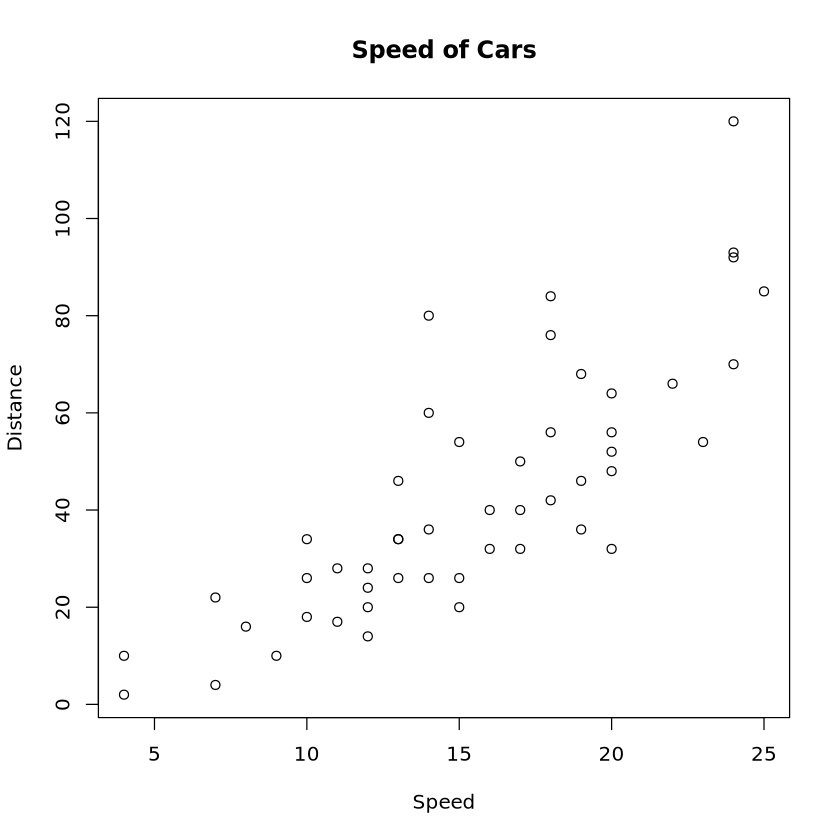

In [11]:
data("cars")
#scatter plot of distance vs speed with x and y axis being determined by xlab and ylab, with the title being determined by main.
plot(cars, ylab = "Distance", xlab = "Speed", main = "Speed of Cars")


### Question 6

Using the `starwars` dataset, identify the individuals with:

- the tallest height
- the lowest mass

HINT: the starwars dataset is part of the dplyr package

In [14]:
#load dplyr package
library("tidyverse")
#load dataframe
data("starwars")

#determines max height of individual
starwars %>% # determines dataframe being used
  group_by(name) %>% # groups dataframe by individuals 
  summarise(max_height = max(height, na.rm = T)) %>% # determines max height of individual in dataframe
  arrange(desc(max_height)) %>%    # arranges output so the max value is top of dataframe
                            head(1)

#determines minimum mass of individual 
starwars %>% #determines dataframe being used
     group_by(name) %>% #groups dataframe by individual
     summarise(min_mass = min(mass, na.rm = T))%>% #determines minimum mass of individual
     arrange(min_mass) %>%   #arranges new column by the minimum mass
                      head(1)

Warning message:
“There were 6 warnings in `summarise()`.
The first warning was:
ℹ In argument: `max_height = max(height, na.rm = T)`.
ℹ In group 4: `name = "Arvel Crynyd"`.
Caused by warning in `max()`:
! no non-missing arguments to max; returning -Inf
ℹ Run `dplyr::last_dplyr_warnings()` to see the 5 remaining warnings.”


name,max_height
<chr>,<dbl>
Yarael Poof,264


Warning message:
“There were 28 warnings in `summarise()`.
The first warning was:
ℹ In argument: `min_mass = min(mass, na.rm = T)`.
ℹ In group 4: `name = "Arvel Crynyd"`.
Caused by warning in `min()`:
! no non-missing arguments to min; returning Inf
ℹ Run `dplyr::last_dplyr_warnings()` to see the 27 remaining warnings.”


name,min_mass
<chr>,<dbl>
Ratts Tyerell,15


### Question 7

The `dplyr` dataset `storms` is part of the US National Oceanic and Atmospheric Administration database of Atlantic hurricanes. It contains multiple repeated measurements from hurricanes. For a given storm, there are measurements from every 6 hours across the life time of the storm.

Use a tidyverse approach with `dplyr` to answer the following:

- how many different storms are contained in the database?
- which year had the most storms?
- which storm, in which year had the highest pressure?

HINT:
unique() will help ensure you remove duplicated data from a vector e.g.
x <- c(1, 1, 2, 2, 3, 3, 4, 4)
unique(x)

In [45]:
# how many different storms
data("storms")
unique(storms) %>% # loads the dataframe while removing repeated values
distinct(name)%>% # determines number of unique values in the "name" column there are 
count() # counts the number of unique names in column to determine number of unique storms 

#which year had the most storms
unique(storms) %>% #
group_by(year, name)%>%
summarise(max_year = max(name, na.rm = T )) %>%
count() %>%
arrange(desc(n)) %>%
head(1)

#which storm, in which year had the highest pressure
unique(storms) %>%
group_by(name) %>%
summarise_at(c("year", "pressure"), mean, na.rm = T) %>%
arrange(desc(pressure)) %>%
head(1)





n
<int>
258


`summarise()` has grouped output by 'year'. You can override using the `.groups` argument.


year,n
<dbl>,<int>
2020,30


name,year,pressure
<chr>,<dbl>,<dbl>
AL072003,2003,1019.143


### Question 8

The `ggplot2` dataset `diamonds` contains the price and information from the sale of 54,000 different diamonds. You can use ?diamonds to find out more about the dataset if you want.

Using `ggplot2`:

- plot the relationship between the carat (i.e. the weight of the diamond) and the price.
- plot a histogram of prices of all the diamonds
- plot a boxplot of the difference in price between the different cuts

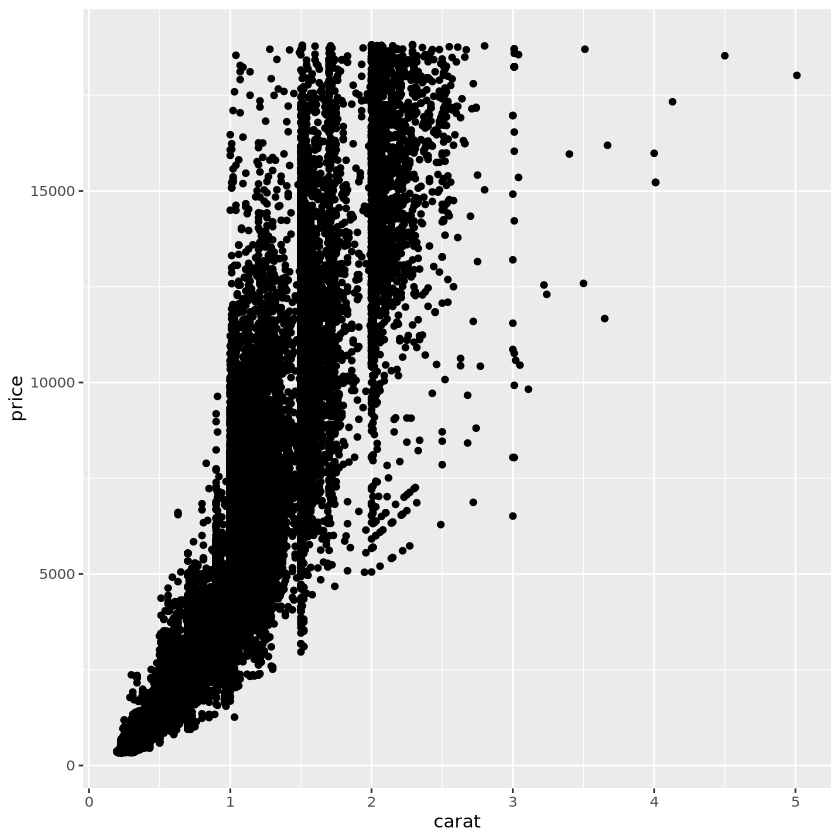

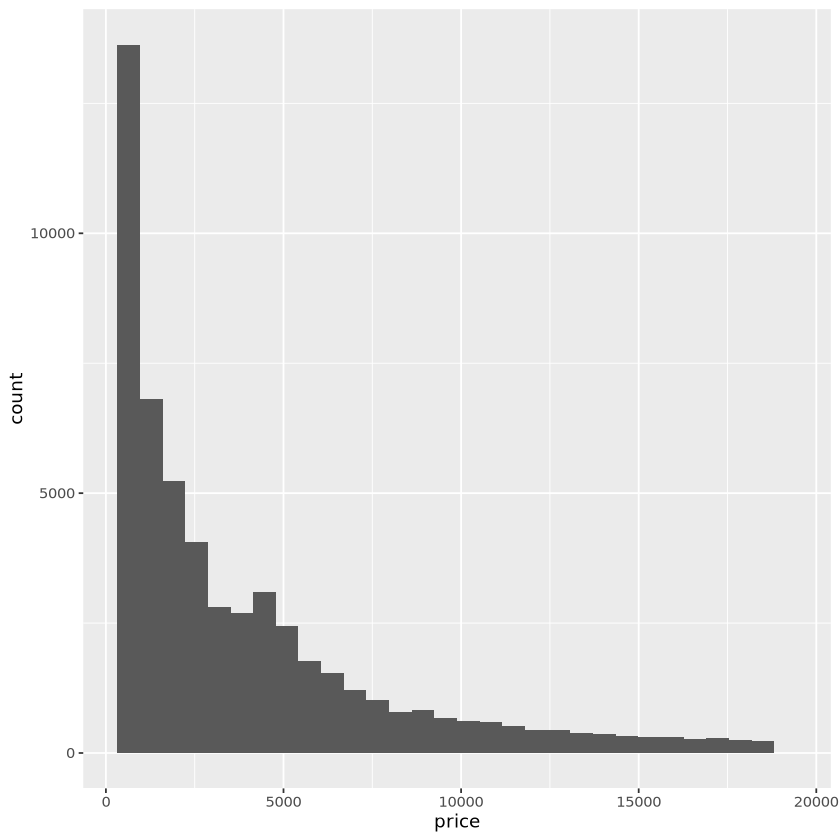

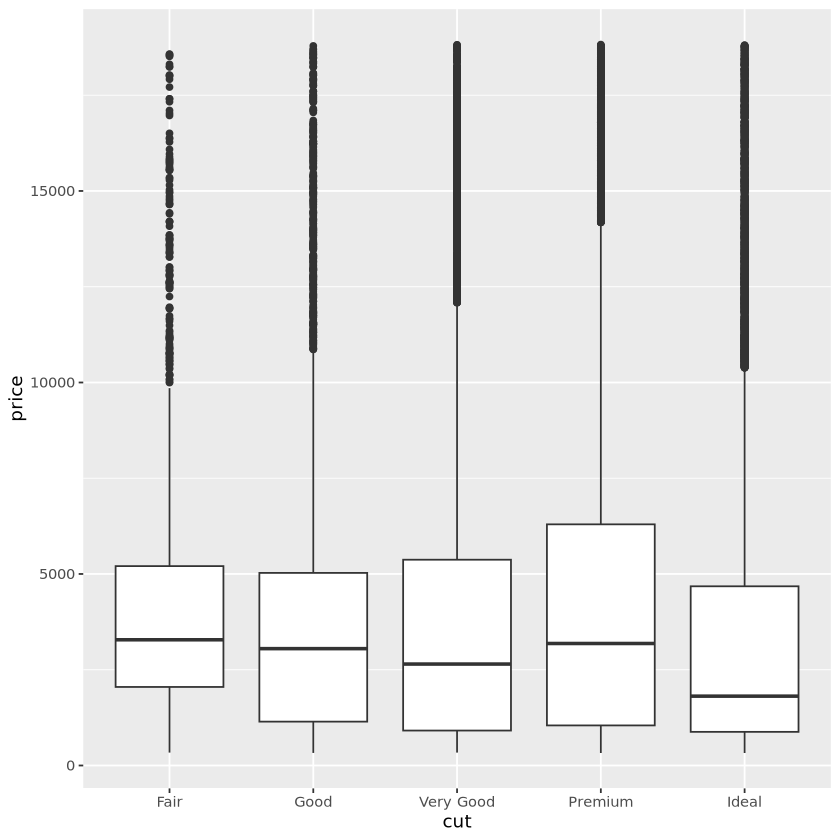

In [47]:
#scatter plot of carat vs price
data("diamonds")
ggplot(diamonds, aes(carat, price)) +
geom_point()

#histogram of price of diamonds
ggplot(diamonds, aes (price)) +
geom_histogram(bins = 30)

#boxplot of price vs cut
ggplot(diamonds, aes(cut, price)) + 
geom_boxplot()

### Question 9

Identify the maximum and minimum price that the diamonds in the diamonds data set sold for. Add a new column to the diamonds data set that contains the string “Low price” if the value in the price column is less than 5000 dollars and “High price” if it is above 5000 dollars.

In [15]:
diamonds$Price_new <- ifelse(diamonds$price < 5000, "low price", 
                             ifelse (diamonds$price > 5000, "High price", 
                                     ifelse (diamonds$price, "NA"))) 



carat,cut,color,clarity,depth,table,price,x,y,z,Price_new
<dbl>,<ord>,<ord>,<ord>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<chr>
0.23,Ideal,E,SI2,61.5,55,326,3.95,3.98,2.43,low price
0.21,Premium,E,SI1,59.8,61,326,3.89,3.84,2.31,low price
0.23,Good,E,VS1,56.9,65,327,4.05,4.07,2.31,low price
0.29,Premium,I,VS2,62.4,58,334,4.20,4.23,2.63,low price
0.31,Good,J,SI2,63.3,58,335,4.34,4.35,2.75,low price
0.24,Very Good,J,VVS2,62.8,57,336,3.94,3.96,2.48,low price
0.24,Very Good,I,VVS1,62.3,57,336,3.95,3.98,2.47,low price
0.26,Very Good,H,SI1,61.9,55,337,4.07,4.11,2.53,low price
0.22,Fair,E,VS2,65.1,61,337,3.87,3.78,2.49,low price


### Question 10

Sticking with the `diamonds` dataset for this question. A carat is a special unit of weight for gemstones where a single carat is 200 mg or 0.2 g. Write a function to convert the `diamonds$carat` vector into grams or milligrams. How heavy is the heaviest diamond?

In [16]:
convert_carat <- function(x){
    y <- x / 5
    return(y)
}
diamonds$new_mass <- sapply(diamonds$carat, convert_carat)
diamonds

diamonds %>% 
group_by(new_mass) %>%
filter(new_mass > 1)

carat,cut,color,clarity,depth,table,price,x,y,z,new_mass
<dbl>,<ord>,<ord>,<ord>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
0.23,Ideal,E,SI2,61.5,55,326,3.95,3.98,2.43,0.046
0.21,Premium,E,SI1,59.8,61,326,3.89,3.84,2.31,0.042
0.23,Good,E,VS1,56.9,65,327,4.05,4.07,2.31,0.046
0.29,Premium,I,VS2,62.4,58,334,4.20,4.23,2.63,0.058
0.31,Good,J,SI2,63.3,58,335,4.34,4.35,2.75,0.062
0.24,Very Good,J,VVS2,62.8,57,336,3.94,3.96,2.48,0.048
0.24,Very Good,I,VVS1,62.3,57,336,3.95,3.98,2.47,0.048
0.26,Very Good,H,SI1,61.9,55,337,4.07,4.11,2.53,0.052
0.22,Fair,E,VS2,65.1,61,337,3.87,3.78,2.49,0.044


carat,cut,color,clarity,depth,table,price,x,y,z,new_mass
<dbl>,<ord>,<ord>,<ord>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
5.01,Fair,J,I1,65.5,59,18018,10.74,10.54,6.98,1.002
